# Fraud Detection

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix,roc_curve,auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib

In [2]:
#loading the dataset to a pandas DataFrame
data=pd.read_csv("D:/5th Sem/New_Series/Advance Project/Project-4/dataset.csv")

In [3]:
# printing the first 5 values of the dataset
data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
data['trans_date_trans_time'] = pd.to_datetime(data['trans_date_trans_time'])
data['hour'] = data['trans_date_trans_time'].dt.hour
data['day'] = data['trans_date_trans_time'].dt.day
data['month'] = data['trans_date_trans_time'].dt.month

In [6]:
drop_columns = ['Unnamed: 0','trans_date_trans_time','first','last','street','city','state','zip',
               'dob','job','trans_num']
data = data.drop(columns= drop_columns)

In [7]:
cat_col = ['merchant','category','gender']
encoders = {}
for col in cat_col:
    encoders[col] = LabelEncoder()
    data[col] = encoders[col].fit_transform(data[col])

In [8]:
data.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month
0,2703186189652095,514,8,4.97,0,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1
1,630423337322,241,4,107.23,0,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1
2,38859492057661,390,0,220.11,1,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1
3,3534093764340240,360,2,45.00,1,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1
4,375534208663984,297,9,41.96,1,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1


In [9]:
def haversine(lat1,lon1,lat2,lon2):
    return np.array([geodesic((a,b),(c,d)).km for a,b,c,d in zip(lat1,lon1,lat2,lon2)])
data['distance'] = haversine(data['lat'],data['long'],data['merch_lat'],data['merch_long'])

In [10]:
# seperating the datasets
features=['merchant','category','amt','cc_num','hour','day','month','gender','distance']
x=data[features]
y=data['is_fraud']

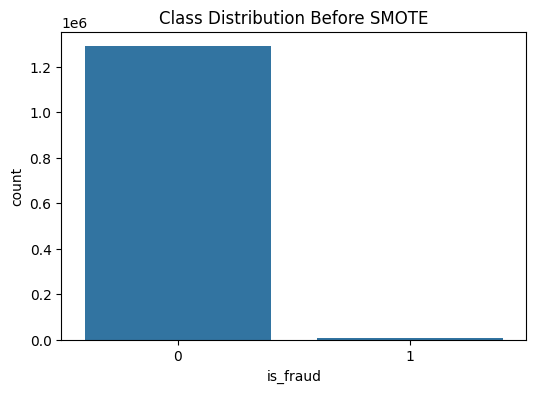

In [11]:
# plotting a graph
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=data)
plt.title("Class Distribution Before SMOTE")
plt.savefig("Distribution_plot.png") 
plt.show()

In [13]:
smote = SMOTE(random_state=42)
x_resample , y_resample = smote.fit_resample(x,y)

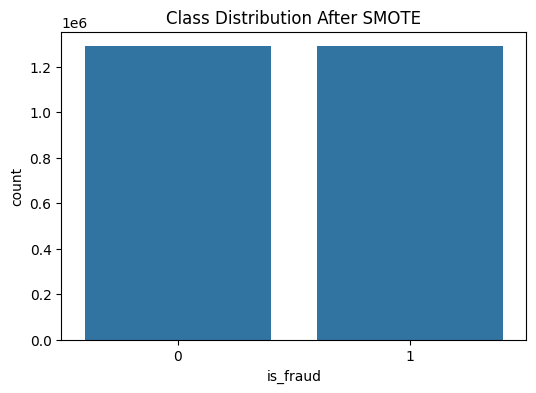

In [14]:
# plotting a graph
plt.figure(figsize=(6,4))
sns.countplot(x=y_resample)
plt.title("Class Distribution After SMOTE")
plt.savefig("Dist_after_SMOTE.png") 
plt.show()

# Train-Test-Split

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x_resample,y_resample,test_size=0.2,random_state=42)

# LGB Classifier

In [16]:
model = lgb.LGBMClassifier(
    objective='binary',
    learning_rate=0.05,
    n_estimators=400,
    max_depth=-1,
    num_leaves=63,
    min_data_in_leaf=20
)

model.fit(x_train, y_train)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 1030687, number of negative: 1031983
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.342611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1105
[LightGBM] [Info] Number of data points in the train set: 2062670, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499686 -> initscore=-0.001257
[LightGBM] [Info] Start training from score -0.001257


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
y_pred = model.predict(x_test)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


In [18]:
print("Classification Report: \n" , classification_report(y_test,y_pred))
print("Roc AUC Score: " , roc_auc_score(y_test ,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.98      0.97    257186
           1       0.98      0.96      0.97    258482

    accuracy                           0.97    515668
   macro avg       0.97      0.97      0.97    515668
weighted avg       0.97      0.97      0.97    515668

Roc AUC Score:  0.9738121230011211


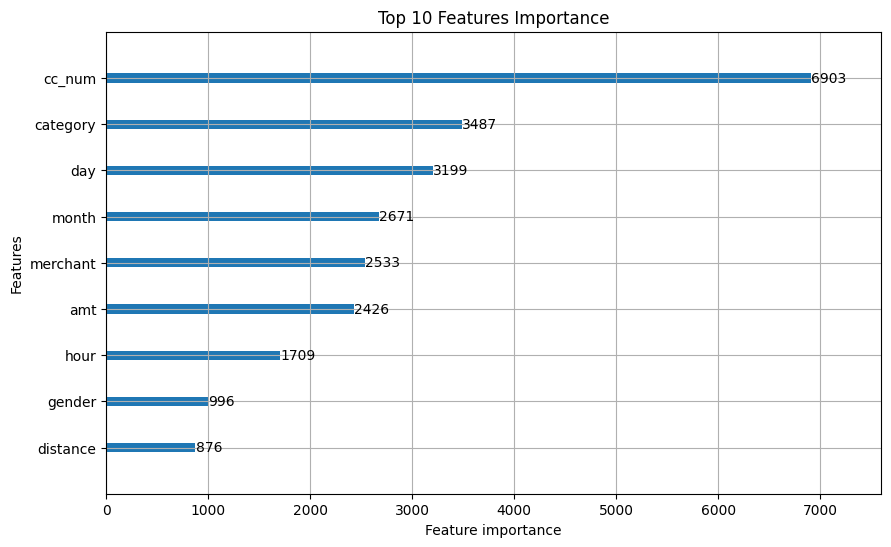

In [19]:
lgb.plot_importance(model ,max_num_features=10,importance_type ='split', figsize=(10,6))
plt.title("Top 10 Features Importance")
plt.savefig("features_plot.png") 
plt.show()

In [20]:
fpr, tpr ,thresholds =roc_curve(y_test ,model.predict_proba(x_test)[:,-1])
roc_auc = auc(fpr ,tpr)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


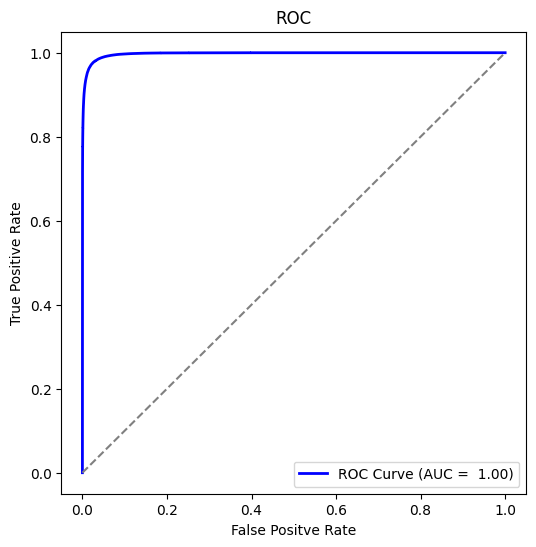

In [21]:
plt.figure(figsize=(6,6))
plt.plot(fpr ,tpr ,color='blue' ,lw=2 ,label=f'ROC Curve (AUC = {roc_auc: .2f})')
plt.plot([0,1],[0,1], color ='gray', linestyle = '--')
plt.title('ROC')
plt.xlabel('False Positve Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc = 'lower right')
plt.savefig("ROC_plot.png") 
plt.show()

# Job-Lib

In [22]:
joblib.dump (model,"fraud_detection_model.pkl")
joblib.dump(encoders, "label_encoder.[pkl")

['label_encoder.pkl']